In [52]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import random
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_predict
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from palmerpenguins import load_penguins
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
#import graphviz
#from sklearn.tree import convert_to_graphviz


%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('ggplot')

train_data = pd.read_csv("./csv/train.csv",  encoding='latin-1')

saleprice_summary = train_data["SalePrice"].describe()

# Calcular percentiles para definir los rangos de clasificación
q1 = train_data["SalePrice"].quantile(0.33)  # 33% más barato
q2 = train_data["SalePrice"].quantile(0.66)  # 66% intermedio
print(q1, q2,  train_data["SalePrice"].max())

# Crear la nueva variable categórica basada en los percentiles
train_data["PriceCategory"] = pd.cut(train_data["SalePrice"], 
                             bins=[train_data["SalePrice"].min(), q1, q2, train_data["SalePrice"].max()], 
                             labels=[0, 1, 2], #"Económica (0)", "Intermedia(1)", "Cara(2)" 
                             include_lowest=True)

# Mostrar resumen de la variable categórica creada
train_data.head()

139000.0 189893.00000000006 755000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,PriceCategory
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,2
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,1
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,2
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,1
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,2


# Exploracion de Variables

In [53]:
train_data.shape

(1460, 82)

In [54]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int64   
 1   MSSubClass     1460 non-null   int64   
 2   MSZoning       1460 non-null   object  
 3   LotFrontage    1201 non-null   float64 
 4   LotArea        1460 non-null   int64   
 5   Street         1460 non-null   object  
 6   Alley          91 non-null     object  
 7   LotShape       1460 non-null   object  
 8   LandContour    1460 non-null   object  
 9   Utilities      1460 non-null   object  
 10  LotConfig      1460 non-null   object  
 11  LandSlope      1460 non-null   object  
 12  Neighborhood   1460 non-null   object  
 13  Condition1     1460 non-null   object  
 14  Condition2     1460 non-null   object  
 15  BldgType       1460 non-null   object  
 16  HouseStyle     1460 non-null   object  
 17  OverallQual    1460 non-null   in

### Columnas que NO sirven:
- Id - identificador único, no aporta valor predictivo.

- Alley, PoolQC, Fence, MiscFeature - demasiados valores nulos (>75%).

- Utilities - tiene casi un solo valor (AllPub), no aporta variabilidad.

- FireplaceQu, GarageYrBlt, GarageQual, GarageCond - muchos nulos y posible colinealidad con otras características más completas.

### Estas columnas tienen demasiadas categorías

- Neighborhood (25)
- Condition1 (9)
- Condition2 (8)
- RoofMatl (8)
- Exterior1st (15)
- Exterior2nd (16)

In [55]:
train_data.drop(columns=["Id","Alley","PoolQC", "Fence", "MiscFeature", "Utilities", "FireplaceQu", "GarageYrBlt", "GarageQual", "GarageCond", "MasVnrType"],axis=1, inplace=True)

In [56]:
columns_to_drop = [
    "Neighborhood", "Condition1", "Condition2",
    "RoofMatl", "Exterior1st", "Exterior2nd"
]
train_data.drop(columns=columns_to_drop, inplace=True)

In [57]:
train_data.shape
train_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,LotConfig,LandSlope,BldgType,...,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,PriceCategory
0,60,RL,65.0,8450,Pave,Reg,Lvl,Inside,Gtl,1Fam,...,0,0,0,0,2,2008,WD,Normal,208500,2
1,20,RL,80.0,9600,Pave,Reg,Lvl,FR2,Gtl,1Fam,...,0,0,0,0,5,2007,WD,Normal,181500,1
2,60,RL,68.0,11250,Pave,IR1,Lvl,Inside,Gtl,1Fam,...,0,0,0,0,9,2008,WD,Normal,223500,2
3,70,RL,60.0,9550,Pave,IR1,Lvl,Corner,Gtl,1Fam,...,0,0,0,0,2,2006,WD,Abnorml,140000,1
4,60,RL,84.0,14260,Pave,IR1,Lvl,FR2,Gtl,1Fam,...,0,0,0,0,12,2008,WD,Normal,250000,2


In [58]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 65 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   MSSubClass     1460 non-null   int64   
 1   MSZoning       1460 non-null   object  
 2   LotFrontage    1201 non-null   float64 
 3   LotArea        1460 non-null   int64   
 4   Street         1460 non-null   object  
 5   LotShape       1460 non-null   object  
 6   LandContour    1460 non-null   object  
 7   LotConfig      1460 non-null   object  
 8   LandSlope      1460 non-null   object  
 9   BldgType       1460 non-null   object  
 10  HouseStyle     1460 non-null   object  
 11  OverallQual    1460 non-null   int64   
 12  OverallCond    1460 non-null   int64   
 13  YearBuilt      1460 non-null   int64   
 14  YearRemodAdd   1460 non-null   int64   
 15  RoofStyle      1460 non-null   object  
 16  MasVnrArea     1452 non-null   float64 
 17  ExterQual      1460 non-null   ob

### Transformacion

In [59]:
# Separar columnas numéricas y categóricas
numeric_cols = train_data.select_dtypes(include=["float64", "int64"]).columns
categorical_cols = train_data.select_dtypes(include=["object"]).columns

# Guardar tipos originales
original_dtypes = train_data[numeric_cols].dtypes

# Imputación para columnas numéricas
num_imputer = SimpleImputer(strategy="median")
imputed_numeric = pd.DataFrame(num_imputer.fit_transform(train_data[numeric_cols]),
                               columns=numeric_cols,
                               index=train_data.index)

# Convertir cada columna al tipo original
for col in numeric_cols:
    imputed_numeric[col] = imputed_numeric[col].astype(original_dtypes[col])

train_data[numeric_cols] = imputed_numeric

# One-hot encoding para columnas categóricas
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(train_data[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols), index=train_data.index)

# Reemplazar columnas categóricas con las codificadas
train_data = train_data.drop(columns=categorical_cols)
train_data = pd.concat([train_data, encoded_df], axis=1)

In [63]:
train_data.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


# Variable respuesta
Sera nuestra variable Price Category
```
Económica (0), Intermedia(1), Cara(2) 
```

In [64]:
train_data.groupby('PriceCategory').size()

C:\Users\thiag\AppData\Local\Temp\ipykernel_10300\3477232259.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_data.groupby('PriceCategory').size()


PriceCategory
0    483
1    480
2    497
dtype: int64

C:\Users\thiag\AppData\Local\Temp\ipykernel_10300\4078800135.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diccEspecie = {'Categoria': train_data['PriceCategory'].unique(), 'Cantidad': train_data.groupby('PriceCategory').size()}


<Axes: xlabel='Categoria', ylabel='Cantidad'>

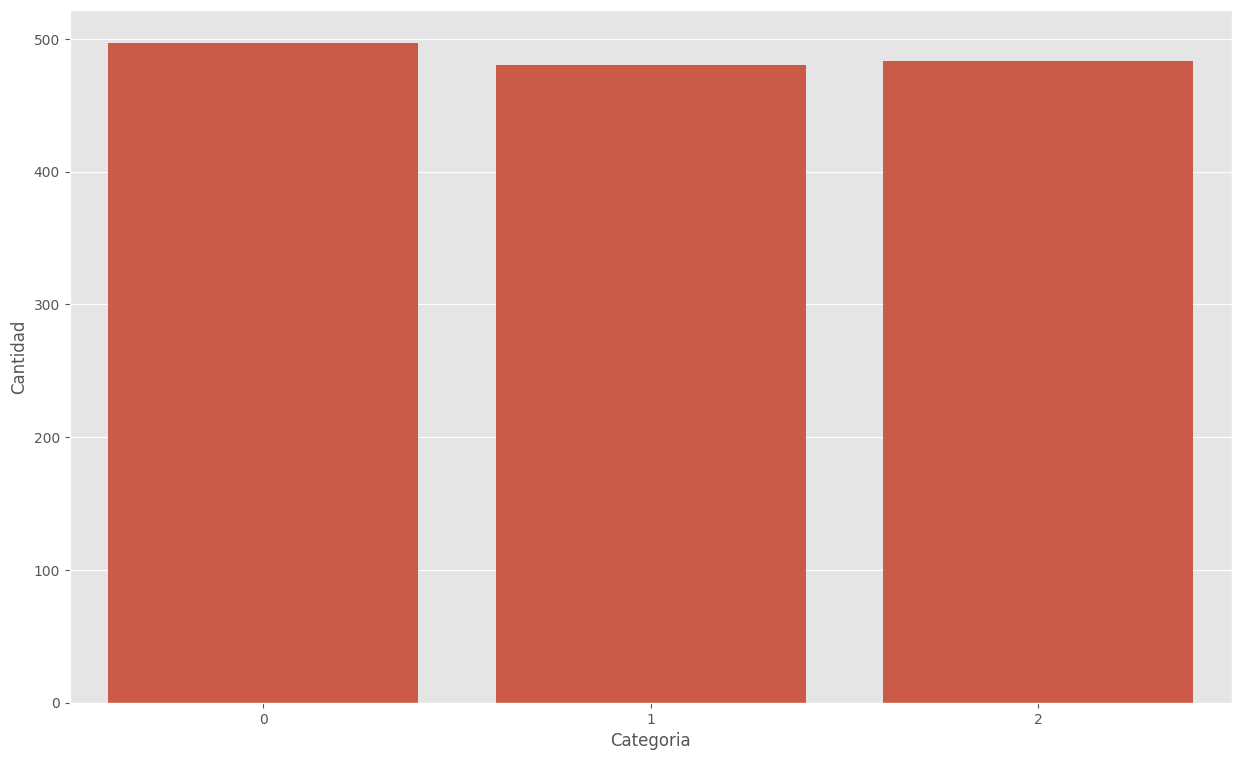

In [65]:
diccEspecie = {'Categoria': train_data['PriceCategory'].unique(), 'Cantidad': train_data.groupby('PriceCategory').size()}
tbl_Specie = pd.DataFrame(diccEspecie)
sb.barplot(x="Categoria",y="Cantidad", data=tbl_Specie)

# Modelos

### Modelo Con C normal y Kernel Lineal

In [66]:
target = train_data.pop('PriceCategory')
data = train_data

In [67]:
random.seed(123)
data_train, data_test,target_train, target_test = train_test_split(data, target,test_size=0.3,train_size=0.7)
data_train.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=153)

In [68]:
modelo = SVC(kernel='linear')
modelo

SVC(kernel='linear')

In [76]:
_=modelo.fit(data_train,target_train)
modelo.score(data_test,target_test)

0.9794520547945206

### Modelo con C normal y Kernel Polinomial

In [73]:
modelo = SVC(kernel='poly')
param_grid = {
    'C': (0.01, 0.1, 1, 5, 16, 32),
    'degree': (2, 3, 5, 7)
}

model_grid_search = GridSearchCV(modelo, param_grid=param_grid, n_jobs=2, cv=10)
model_grid_search.fit(data_train, target_train)

GridSearchCV(cv=10, estimator=SVC(kernel='poly'), n_jobs=2,
             param_grid={'C': (0.01, 0.1, 1, 5, 16, 32),
                         'degree': (2, 3, 5, 7)})

In [74]:
accuracy = model_grid_search.score(data_test, target_test)
print("Accuracy:", accuracy)
model_grid_search.best_params_

Accuracy: 1.0


{'C': 32, 'degree': 2}

### Modelo con C normal y Kernel Gaussiano

In [78]:
modelo = SVC(kernel="rbf")
param_grid = {
    'C': (0.01, 0.1, 1, 5, 16, 32),
    'gamma': (2e-10, 2e-5, 0.01, 0.1, 20, 200)
}

model_grid_search = GridSearchCV(modelo, param_grid=param_grid,
                                 n_jobs=2, cv=10)
model_grid_search.fit(data_train, target_train)


GridSearchCV(cv=10, estimator=SVC(), n_jobs=2,
             param_grid={'C': (0.01, 0.1, 1, 5, 16, 32),
                         'gamma': (2e-10, 2e-05, 0.01, 0.1, 20, 200)})

In [79]:
accuracy = model_grid_search.score(data_test, target_test)
print("Accuracy:", accuracy)

Accuracy: 1.0
